In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
# 1. Download the latest version of the dataset
path = kagglehub.dataset_download("mizanunswcyber/arp-spoofing-based-mitm-attack-dataset")
print("Path to dataset files:", path)

100%|██████████| 9.04M/9.04M [00:00<00:00, 63.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mizanunswcyber/arp-spoofing-based-mitm-attack-dataset/versions/1


In [3]:
# 2. Locate the CSV file in the downloaded folder
files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, files[0])
df = pd.read_csv(csv_path)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 74343 rows, 79 columns


In [4]:
df.head()

,src_port,dst_port,protocol,ip_version,vlan_id,tunnel_id,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Label
0,56343,443,6,4,0,0,1.666040e+12,1.666040e+12,904,20,...,TLS,Web,0,6,apicom.netatmo.net,bb32cf215dd58fdee6573e65933e6c55,NaN,NaN,NaN,normal
1,0,0,2,4,0,0,1.666040e+12,1.666040e+12,231,2,...,IGMP,Network,0,6,apicom.netatmo.net,bb32cf215dd58fdee6573e65933e6c55,NaN,NaN,NaN,normal
2,43586,443,6,4,0,0,1.666040e+12,1.666040e+12,40,3,...,TLS,Web,0,6,apicom.netatmo.net,bb32cf215dd58fdee6573e65933e6c55,NaN,NaN,NaN,normal
3,5353,5353,17,4,0,0,1.666040e+12,1.666040e+12,0,1,...,MDNS,Network,0,6,amazon-c1a898e49-mshome-net.local,bb32cf215dd58fdee6573e65933e6c55,NaN,NaN,NaN,normal
4,0,0,1,4,0,0,1.666040e+12,1.666040e+12,0,1,...,ICMP,Network,0,6,amazon-c1a898e49-mshome-net.local,bb32cf215dd58fdee6573e65933e6c55,NaN,NaN,NaN,arp_spoofing


,src_port,dst_port,protocol,ip_version,vlan_id,tunnel_id,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Label
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74338,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
74339,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
74340,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
74341,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

,0
src_port,0
dst_port,0
protocol,0
ip_version,0
vlan_id,0
...,...
client_fingerprint,0
server_fingerprint,7
user_agent,218
content_type,218


In [8]:
pd.set_option('display.max_columns', None)
print(df.isnull().sum())

src_port                0
dst_port                0
protocol                0
ip_version              0
vlan_id                 0
                     ... 
client_fingerprint      0
server_fingerprint      7
user_agent            218
content_type          218
Label                   0
Length: 79, dtype: int64


In [9]:
df.describe()

,src_port,dst_port,protocol,ip_version,vlan_id,tunnel_id,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms,src2dst_last_seen_ms,src2dst_duration_ms,src2dst_packets,src2dst_bytes,dst2src_first_seen_ms,dst2src_last_seen_ms,dst2src_duration_ms,dst2src_packets,dst2src_bytes,bidirectional_min_ps,bidirectional_mean_ps,bidirectional_stddev_ps,bidirectional_max_ps,src2dst_min_ps,src2dst_mean_ps,src2dst_stddev_ps,src2dst_max_ps,dst2src_min_ps,dst2src_mean_ps,dst2src_stddev_ps,dst2src_max_ps,bidirectional_min_piat_ms,bidirectional_mean_piat_ms,bidirectional_stddev_piat_ms,bidirectional_max_piat_ms,src2dst_min_piat_ms,src2dst_mean_piat_ms,src2dst_stddev_piat_ms,src2dst_max_piat_ms,dst2src_min_piat_ms,dst2src_mean_piat_ms,dst2src_stddev_piat_ms,dst2src_max_piat_ms,bidirectional_syn_packets,bidirectional_cwr_packets,bidirectional_ece_packets,bidirectional_urg_packets,bidirectional_ack_packets,bidirectional_psh_packets,bidirectional_rst_packets,bidirectional_fin_packets,src2dst_syn_packets,src2dst_cwr_packets,src2dst_ece_packets,src2dst_urg_packets,src2dst_ack_packets,src2dst_psh_packets,src2dst_rst_packets,src2dst_fin_packets,dst2src_syn_packets,dst2src_cwr_packets,dst2src_ece_packets,dst2src_urg_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,application_is_guessed,application_confidence
count,74343.000000,74343.000000,74343.000000,74343.000000,74343.0,74343.000000,7.434300e+04,7.434300e+04,74343.000000,74343.000000,7.434300e+04,7.434300e+04,7.434300e+04,74343.000000,74343.000000,7.434300e+04,7.434300e+04,7.434300e+04,74343.000000,74343.000000,7.434300e+04,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000,74343.000000
mean,29833.401894,17009.260226,14.542795,4.034220,0.0,0.000121,1.656821e+12,1.656821e+12,28896.468235,43.696407,3.716942e+04,1.656821e+12,1.656821e+12,28669.604993,23.629770,1.071383e+04,1.304561e+12,1.304561e+12,18215.990463,20.066637,2.645560e+04,97.168113,158.784702,100.454935,454.946276,108.298024,142.673748,45.681107,288.550771,77.705877,136.789335,82.956757,343.560577,661.486973,2185.061996,2380.091962,6703.310359,1269.388174,3047.064413,2317.307668,6615.399580,1713.276045,2631.090998,1105.439371,4412.319721,0.390689,0.028099,0.048303,0.001009,31.349757,8.284761,0.097615,0.227849,0.240695,0.025530,0.023526,0.000821,15.843106,2.031207,0.073564,0.126575,0.149994,0.002569,0.024777,0.000188,15.506652,6.253554,0.024051,0.101274,0.057975,4.738039
std,23205.356712,21490.473975,6.841230,0.259364,0.0,0.019057,9.684270e+10,9.684270e+10,78075.477300,1818.194699,2.134008e+06,9.684270e+10,9.684270e+10,78002.848605,1011.644255,4.878514e+05,6.853815e+11,6.853815e+11,62867.612347,827.173154,1.997939e+06,96.975639,173.205363,240.628467,1164.710178,100.809401,185.812487,176.157674,923.764620,66.394565,240.348737,264.047574,854.491578,6052.481990,8094.403976,7549.531437,18406.835237,7874.721379,10041.119537,7877.851887,18344.979302,9787.225835,10695.447129,4797.890451,14488.388130,1.074374,0.259347,0.361656,0.048507,1766.963107,613.935511,0.529263,0.824841,0.707772,0.180331,0.155856,0.034199,972.719964,79.218664,0.444018,0.602637,0.505870,0.159383,0.236279,0.023195,800.642332,608.247890,0.268488,0.371073,0.233697,2.384699
min,0.000000,0.000000,1.000000,4.000000,0.0,0.000000,1.752000e+04,1.752200e+04,0.000000,1.000000,4.200000e+01

In [12]:
df.columns

Index(['src_port', 'dst_port', 'protocol', 'ip_version', 'vlan_id',
       'tunnel_id', 'bidirectional_first_seen_ms',
       'bidirectional_last_seen_ms', 'bidirectional_duration_ms',
       'bidirectional_packets', 'bidirectional_bytes', 'src2dst_first_seen_ms',
       'src2dst_last_seen_ms', 'src2dst_duration_ms', 'src2dst_packets',
       'src2dst_bytes', 'dst2src_first_seen_ms', 'dst2src_last_seen_ms',
       'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes',
       'bidirectional_min_ps', 'bidirectional_mean_ps',
       'bidirectional_stddev_ps', 'bidirectional_max_ps', 'src2dst_min_ps',
       'src2dst_mean_ps', 'src2dst_stddev_ps', 'src2dst_max_ps',
       'dst2src_min_ps', 'dst2src_mean_ps', 'dst2src_stddev_ps',
       'dst2src_max_ps', 'bidirectional_min_piat_ms',
       'bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms',
       'bidirectional_max_piat_ms', 'src2dst_min_piat_ms',
       'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 'src2dst_max_piat_ms',

In [13]:
# 3. Basic Preprocessing
# Drop non-numeric/metadata columns that won't help the model
# We also drop the 'label' to treat this as an unsupervised task
target_col = 'Label' # Adjust if the column name is different (e.g., 'Label' or 'Class')
X = df.select_dtypes(include=[np.number]).drop(columns=[target_col], errors='ignore')
y = df[target_col]

In [14]:
X = X.fillna(0)

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# 4. Initialize and Train Isolation Forest
# contamination: The proportion of outliers in the data.
# If you don't know it, you can set it to 'auto'.
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
y_pred = iso_forest.fit_predict(X_scaled)

# Convert Isolation Forest output: 1 (normal) -> 0, -1 (anomaly) -> 1
# This assumes your 'y' labels are 0 for normal and 1 for attack.
y_pred_mapped = np.where(y_pred == 1, 0, 1)

In [24]:
# 5. Evaluation
# Map 'normal' to 0 and 'arp_spoofing' to 1 in y to match y_pred_mapped
y_mapped = y.map({'normal': 0, 'arp_spoofing': 1})

print("\n--- Isolation Forest Performance Report ---")
print(classification_report(y_mapped, y_pred_mapped))


--- Isolation Forest Performance Report ---
              precision    recall  f1-score   support

           0       0.49      0.84      0.62     39551
           1       0.13      0.03      0.05     34792

    accuracy                           0.46     74343
   macro avg       0.31      0.43      0.33     74343
weighted avg       0.32      0.46      0.35     74343



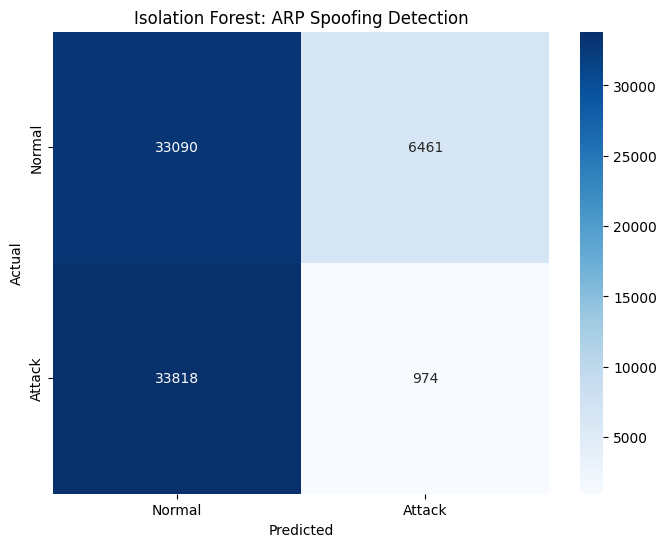

In [20]:
# 6. Visualization: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_mapped, y_pred_mapped)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Isolation Forest: ARP Spoofing Detection')
plt.show()

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Get the number of features from X_scaled
input_dim = X_scaled.shape[1]

# Define the encoder architecture
input_layer = Input(shape=(input_dim,))
encoder = Dense(64, activation="relu")(input_layer)
encoder = Dense(32, activation="relu")(encoder)

# Define the decoder architecture
decoder = Dense(64, activation="relu")(encoder)
decoder = Dense(input_dim, activation="linear")(decoder) # Output layer matches input dimensions

# Create the autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
print("\n--- Training Autoencoder ---")
history = autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=256, shuffle=True, validation_split=0.2, verbose=1)

print("Autoencoder training complete.")


--- Training Autoencoder ---
Epoch 1/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4635 - val_loss: 0.9325
Epoch 2/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2062 - val_loss: 0.8700
Epoch 3/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1226 - val_loss: 0.8516
Epoch 4/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1086 - val_loss: 0.8809
Epoch 5/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1441 - val_loss: 0.8732
Epoch 6/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1601 - val_loss: 0.8509
Epoch 7/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0743 - val_loss: 0.8454
Epoch 8/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0996 - val_loss: 0.8626
Epoch 9/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1074 - val_loss: 0.8174
Epoch 10/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1232 - val_loss: 0.8060
Epoch 11/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0609 - val_loss: 0.8083
Epoch 12/50
233/233 ━━

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 7. Evaluate Autoencoder for Anomaly Detection

# Get reconstructions from the autoencoder
X_reconstructed = autoencoder.predict(X_scaled)

# Calculate reconstruction error (e.g., Mean Squared Error)
mse = np.mean(np.power(X_scaled - X_reconstructed, 2), axis=1)

# Determine anomaly threshold
# A common approach is to set the threshold based on a percentile of the MSE values.
# For example, if we assume 10% anomalies, we can use the 90th percentile as the threshold.
threshold = np.percentile(mse, 90) # Adjust percentile based on expected anomaly rate

# Classify anomalies based on the threshold
y_pred_autoencoder = (mse > threshold).astype(int)

print("\n Autoencoder Performance Report")
print(classification_report(y_mapped, y_pred_autoencoder))

2324/2324 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

 Autoencoder Performance Report
              precision    recall  f1-score   support

           0       0.49      0.83      0.62     39551
           1       0.10      0.02      0.04     34792

    accuracy                           0.45     74343
   macro avg       0.30      0.43      0.33     74343
weighted avg       0.31      0.45      0.35     74343



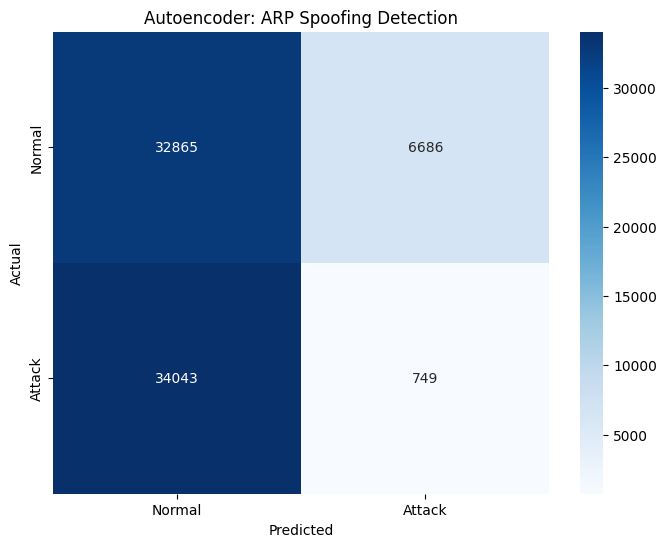

In [27]:
# 8. Visualization: Confusion Matrix for Autoencoder
plt.figure(figsize=(8, 6))
cm_autoencoder = confusion_matrix(y_mapped, y_pred_autoencoder)
sns.heatmap(cm_autoencoder, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Autoencoder: ARP Spoofing Detection')
plt.show()


--- Random Forest Classifier Performance Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39551
           1       1.00      1.00      1.00     34792

    accuracy                           1.00     74343
   macro avg       1.00      1.00      1.00     74343
weighted avg       1.00      1.00      1.00     74343



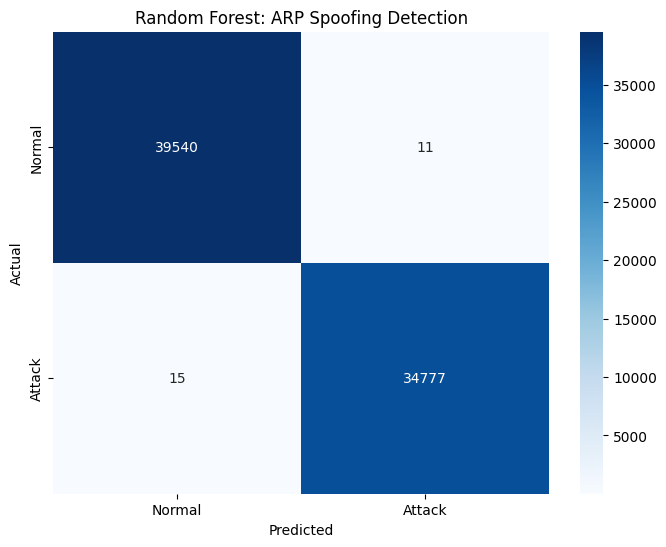

In [28]:
from sklearn.ensemble import RandomForestClassifier

# 9. Initialize and Train Random Forest Classifier
# You can tune n_estimators, max_features, etc., for better performance
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_scaled, y_mapped)

# Make predictions
y_pred_rf = rf_classifier.predict(X_scaled)

print("\n--- Random Forest Classifier Performance Report ---")
print(classification_report(y_mapped, y_pred_rf))

# 10. Visualization: Confusion Matrix for Random Forest
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_mapped, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest: ARP Spoofing Detection')
plt.show()